In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
# import pandas_ta
# import talib

# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *


import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline


In [2]:
def skip_first_fn(params):
    skip_first = max(params['tenkan_period'], params['kijun_period'], params['senkou_span_b_period'] + params['chikou_span_delay'])
    return skip_first


def calculate_ichimoku(data, params):
    tenkan_period = params['tenkan_period']
    kijun_period = params['kijun_period']
    senkou_span_b_period = params['senkou_span_b_period']
    chikou_span_delay = params['chikou_span_delay']

    # Tenkan-sen (Conversion Line)
    data['tenkan_sen'] = (data['close'].rolling(window=tenkan_period).max() + 
                          data['close'].rolling(window=tenkan_period).min()) / 2

    # Kijun-sen (Base Line)
    data['kijun_sen'] = (data['close'].rolling(window=kijun_period).max() + 
                         data['close'].rolling(window=kijun_period).min()) / 2

    # Senkou Span A (Leading Span A)
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(chikou_span_delay)

    # Senkou Span B (Leading Span B)
    data['senkou_span_b'] = ((data['close'].rolling(window=senkou_span_b_period).max() + 
                              data['close'].rolling(window=senkou_span_b_period).min()) / 2).shift(chikou_span_delay)

    # Chikou Span (Lagging Span)
    # data['chikou_span'] = data['close'].shift(-chikou_span_delay)
    
    # data['cloud_upper'] = data[['senkou_span_a', 'senkou_span_b']].max(axis=1)
    # data['cloud_lower'] = data[['senkou_span_a', 'senkou_span_b']].min(axis=1)
    
    # data['close_above_cloud'] = data['close'] > data['cloud_upper']
    # data['close_below_cloud'] = data['close'] < data['cloud_lower']
    
    # data['full_bull'] = (
    #     (data['tenkan_sen'] > data['kijun_sen']) &
    #     (data['close_above_cloud']))
    
    # data['full_bear'] = (
    #     (data['tenkan_sen'] < data['kijun_sen']) &
    #     (data['close_below_cloud']))
    

In [3]:

asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
data = load_candles('binance',asset, quote, timeframe)#['2020':'2024']#.iloc[-35000:-5000]
params = {'tenkan_period': 20, 'kijun_period': 60, 'senkou_span_b_period': 120, 'chikou_span_delay': 30}
calculate_ichimoku(data, params)
skip_first = skip_first_fn(params)
data = data.iloc[skip_first:]
data.head(5)

,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b
timestamp,,,,,,,,,
2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.04,3855.5175,3991.455
2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.04,3855.5175,3991.455
2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.04,3855.5175,3991.455
2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.04,3846.2675,3991.455
2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.04,3860.9200,3991.455


2024-09-05 14:46:28.639365: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-05 14:46:28.783478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-05 14:46:28.852533: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-05 14:46:28.870157: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-05 14:46:28.969066: I tensorflow/core/platform/cpu_feature_guar

,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b
timestamp,,,,,,,,,
2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.04,3855.5175,3991.455
2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.04,3855.5175,3991.455
2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.04,3855.5175,3991.455
2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.04,3846.2675,3991.455
2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.04,3860.9200,3991.455


## GYM ANYTRADING

In [ ]:
# Gym stuff
import gym
import gym_anytrading

# Stable baselines - RL stuff
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import A2C

# Processing libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [10]:
%load_ext autoreload
%autoreload 2
# Gym stuff
import gymnasium as gym
import gym_anytrading

from gym_anytrading.envs import TradingEnv, ForexEnv, StocksEnv, Actions, Positions 

# Stable baselines - RL stuff
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import A2C

# Processing libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# gym_anytrading.

SyntaxError: invalid syntax (916634511.py, line 1)

In [12]:
df = data
# Create the environment
env = gym.make('stocks-v0', df=df, frame_bound=(5, 100), window_size=5)

# View environment features
env.signal_features

# View environment prices
env.prices

array([4392.36, 4382.07, 4369.  , 4334.  , 4343.01, 4423.  , 4455.99,
       4590.  , 4640.  , 4584.06, 4664.31, 4786.95, 4785.78, 4831.99,
       4783.06, 4829.99, 4825.01, 4821.43, 5010.2 , 5305.01, 5430.  ,
       5628.02, 5762.25, 5649.98, 5653.41, 5752.04, 5869.99, 5786.11,
       5544.14, 5709.99, 5628.32, 5681.22, 5760.02, 5650.02, 5603.01,
       5595.  , 5277.22, 5322.28, 5512.06, 5577.98, 5625.01, 5683.9 ,
       5639.95, 5889.99, 6010.01, 6091.92, 6149.99, 6024.97, 5907.11,
       5970.27, 5950.02, 5865.05, 5762.04, 5915.93, 5721.83, 5637.96,
       5477.03, 5541.51, 5456.11, 5689.99, 5669.13, 5918.99, 5861.77,
       5874.49, 5771.01, 5768.83, 5781.01, 5669.97, 5719.64, 5799.99,
       5949.01, 6169.98, 6116.19, 6070.98, 6120.5 , 6117.94, 6371.28,
       6463.  , 6415.  , 6596.99, 6753.98, 6934.  , 7019.98, 7019.98,
       7251.01, 7284.98, 7115.04, 7174.99, 7300.  , 7357.09, 7398.69,
       7499.87, 7345.01, 7275.  , 7232.03, 6960.12, 7159.98, 7038.2 ,
       7064.04, 7303

info: {'total_reward': 1908.93896484375, 'total_profit': 0.9549704842694579, 'position': <Positions.Long: 1>}


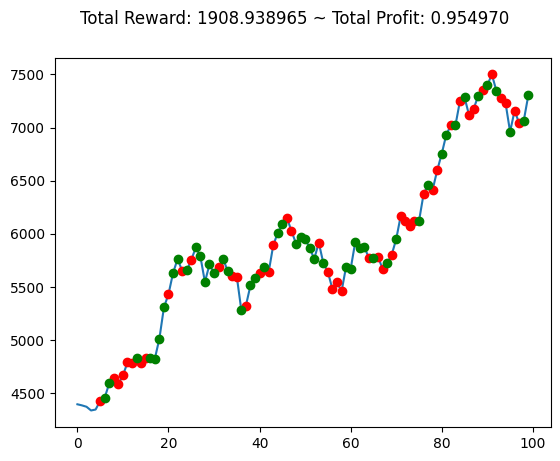

In [13]:

observation = env.reset(seed=2023)
while True:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    # env.render()
    if done:
        print("info:", info)
        break

plt.cla()
env.unwrapped.render_all()
plt.show()

In [15]:
data.columns

Index(['open', 'high', 'low', 'close', 'volume', 'tenkan_sen', 'kijun_sen',
       'senkou_span_a', 'senkou_span_b'],
      dtype='object')

In [17]:
def my_process_data(env):
    start = env.frame_bound[0] - env.window_size
    end = env.frame_bound[1]
    prices = env.df.loc[:, 'close'].to_numpy()[start:end]
    signal_features = env.df.loc[:, ['high', 'low', 'close', 'volume', 'tenkan_sen', 'kijun_sen',
       'senkou_span_a', 'senkou_span_b']].to_numpy()[start:end]
    return prices, signal_features


class MyEnv(ForexEnv):
    _process_data = my_process_data


env = MyEnv(df=data, frame_bound=(5, 100), window_size=5)

info: {'total_reward': 10968500.000000011, 'total_profit': 0.8529134414106017, 'position': <Positions.Long: 1>}


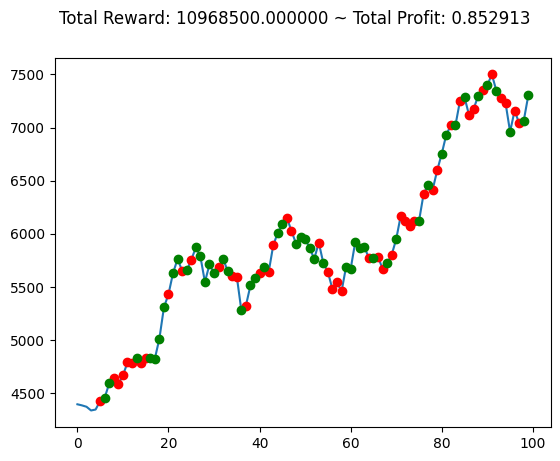

In [18]:
observation = env.reset(seed=2023)
while True:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    # env.render()
    if done:
        print("info:", info)
        break

plt.cla()
env.unwrapped.render_all()
plt.show()

In [19]:
# Creating our dummy vectorizing environment
env_maker = lambda: env #gym.make('stocks-v0', df=df, frame_bound=(5, 100), window_size=5)
env = DummyVecEnv([env_maker])

# Initializing and training the A2C model
model = A2C('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=1000000)

Using cpu device
------------------------------------
| time/                 |          |
|    fps                | 1597     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.0645  |
|    explained_variance | 0        |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 7.19e-05 |
|    value_loss         | 4.42e-05 |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 1674     |
|    iterations         | 200      |
|    time_elapsed       | 0        |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -0.0623  |
|    explained_variance | 0        |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | 1.45e-09 |
|    value_loss      

KeyboardInterrupt: 

In [ ]:
env = gym.make('stocks-v0', df=df, frame_bound=(90, 110), window_size=5)
obs = env.reset()
while True:
    obs = obs[np.newaxis, ...]
    action, _states = model.predict(obs)
    obs, rewards, done, info = env.step(action)
    if done:
        print("info", info)
        break

plt.figure(figsize=(15, 6))
plt.cla()
env.render_all()
plt.show()

## GYM TRADING ENV

In [23]:
df = data.copy().set_axis([f'{c}_feature' for c in data.columns], axis=1)
df

,open_feature,high_feature,low_feature,close_feature,volume_feature,tenkan_sen_feature,kijun_sen_feature,senkou_span_a_feature,senkou_span_b_feature
timestamp,,,,,,,,,
2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.04,3855.5175,3991.455
2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.04,3855.5175,3991.455
2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.04,3855.5175,3991.455
2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.04,3846.2675,3991.455
2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.04,3860.9200,3991.455
...,...,...,...,...,...,...,...,...,...
2024-08-22 00:00:00,61156.03,61229.00,59724.87,60984.31,6786.416910,59348.545,58045.10,59476.7500,61101.100
2024-08-22 08:00:00,60984.31,61400.00,60100.00,60407.40,9948.916940,59613.545,57180.09,59755.5875,61101.100
2024-08-22 16:00:00,60407.39,60707.88,60131.00,60375.84,4505.872030,59613.545,57180.09,59755.5875,61101.100


In [24]:

import gymnasium as gym
import gym_trading_env
from gym_trading_env.environments import TradingEnv
def reward_function(history):
        return np.log(history["portfolio_valuation", -1] / history["portfolio_valuation", -2])

# TradingEnv()
trade_env = gym.make("TradingEnv",
        name= "BTCUSD",
        df = df, # Your dataset with your custom features
        positions = [ -1, 0, 1], # -1 (=SHORT), 0(=OUT), +1 (=LONG)
        trading_fees = 0.01/100, # 0.01% per stock buy / sell (Binance fees)
        borrow_interest_rate= 0.0003/100, # 0.0003% per timestep (one timestep = 1h here)
        reward_function = reward_function
    )

env.unwrapped.add_metric('Position Changes', lambda history : np.sum(np.diff(history['position']) != 0) )
env.unwrapped.add_metric('Episode Lenght', lambda history : len(history['position']) )


KeyError: "None of [Index(['close'], dtype='object')] are in the [columns]"

In [25]:
# Run an episode until it ends :
done, truncated = False, False
observation, info = env.reset()
while not done and not truncated:
    # Pick a position by its index in your position list (=[-1, 0, 1])....usually something like : position_index = your_policy(observation)
    position_index = env.action_space.sample() # At every timestep, pick a random position index from your position list (=[-1, 0, 1])
    observation, reward, done, truncated, info = env.step(position_index)

ValueError: too many values to unpack (expected 2)

In [16]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Create vectorized environment (optional but recommended for parallel processing)
env = make_vec_env(env, n_envs=4)  # You can change 'CartPole-v1' to your custom environment

# Initialize the PPO model
model = PPO("MlpPolicy", env, verbose=1)

# Train the PPO model
model.learn(total_timesteps=1000000)  # You can adjust the number of timesteps


Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 23.6     |
|    ep_rew_mean     | 23.6     |
| time/              |          |
|    fps             | 12429    |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 8192     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 40.9        |
|    ep_rew_mean          | 40.9        |
| time/                   |             |
|    fps                  | 5264        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.014414757 |
|    clip_fraction        | 0.221       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.682      |
|    explained_variance   | -0.00113    |
|    learning

In [17]:
model.save("ppo_ichimoku")

In [18]:
data

,open,high,low,close,volume,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b
timestamp,,,,,,,,,
2017-10-06 00:00:00,4318.99,4410.00,4292.00,4392.36,187.497963,4289.055,3969.04,3855.5175,3991.455
2017-10-06 08:00:00,4396.00,4417.00,4312.57,4382.07,217.913334,4289.055,3969.04,3855.5175,3991.455
2017-10-06 16:00:00,4382.07,4400.00,4315.95,4369.00,101.117879,4289.055,3969.04,3855.5175,3991.455
2017-10-07 00:00:00,4369.00,4399.00,4330.09,4334.00,112.434219,4289.055,3969.04,3846.2675,3991.455
2017-10-07 08:00:00,4335.00,4388.54,4312.56,4343.01,86.377848,4289.055,3969.04,3860.9200,3991.455
...,...,...,...,...,...,...,...,...,...
2024-08-22 00:00:00,61156.03,61229.00,59724.87,60984.31,6786.416910,59348.545,58045.10,59476.7500,61101.100
2024-08-22 08:00:00,60984.31,61400.00,60100.00,60407.40,9948.916940,59613.545,57180.09,59755.5875,61101.100
2024-08-22 16:00:00,60407.39,60707.88,60131.00,60375.84,4505.872030,59613.545,57180.09,59755.5875,61101.100


In [22]:
actions = []
rewards = []
obs = env.reset()
for _ in range(len(data)):
# Get action from the model
    action, _states = model.predict(obs)
    
    # Store the action
    actions.append(action)
    
    # Take the action in the environment
    obs, reward, done, info = env.step(action)
    
    # Store the reward
    rewards.append(reward)
    
    # Render the environment (optional)
    # env.render()
    
    # If the episode is done, reset the environment
    if any(dones):  # dones is a list/array of boolean values
        obs = env.reset()
        obs, info = env.reset()
    

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
    
# env.close()

# Plot actions and rewards
plt.figure(figsize=(20, 5))

# Plot actions
plt.subplot(1, 2, 1)
plt.plot(actions)
plt.title("Actions Over Time")
plt.xlabel("Timesteps")
plt.ylabel("Action")

# Plot rewards
plt.subplot(1, 2, 2)